<a href="https://colab.research.google.com/github/Thanseer-S/DSA_2026/blob/main/REGRESSION_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:

df = pd.read_csv('/content/car_age_price.csv')
print(df.head())

   Year   Price
0  2018  465000
1  2019  755000
2  2019  700000
3  2018  465000
4  2018  465000


In [3]:

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Year    112 non-null    int64
 1   Price   112 non-null    int64
dtypes: int64(2)
memory usage: 1.9 KB
None


In [4]:
print(df.describe())

              Year          Price
count   112.000000     112.000000
mean   2016.669643  483866.044643
std       1.629616   91217.450533
min    2013.000000  300000.000000
25%    2015.000000  423750.000000
50%    2017.000000  500000.000000
75%    2017.000000  550000.000000
max    2020.000000  755000.000000


In [5]:

print(df.isnull().sum())

Year     0
Price    0
dtype: int64


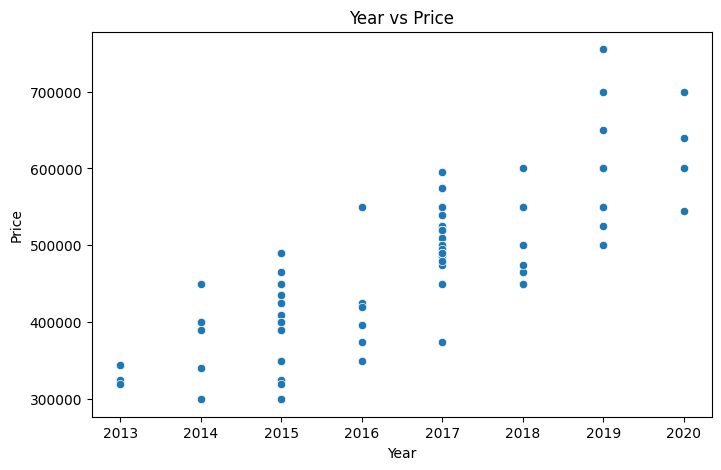

In [6]:

plt.figure(figsize=(8,5))
sns.scatterplot(x='Year', y='Price', data=df)

plt.title("Year vs Price")
plt.show()

In [7]:

X = df[['Year']]

y = df['Price']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (89, 1)
Testing data shape: (23, 1)


In [17]:

lr_model = LinearRegression()


lr_model.fit(X_train, y_train)


lr_pred = lr_model.predict(X_test)

print("Predicted Prices:")
print(lr_pred)

Predicted Prices:
[600775.91252081 505558.77690466 553167.34471273 553167.34471273
 553167.34471273 410341.6412885  505558.77690466 553167.34471273
 600775.91252081 600775.91252081 315124.50567235 505558.77690466
 410341.6412885  648384.48032889 553167.34471273 600775.91252081
 315124.50567235 410341.6412885  505558.77690466 505558.77690466
 505558.77690466 505558.77690466 505558.77690466]


In [19]:

lr_mse = mean_squared_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression MSE:", lr_mse)
print("Linear Regression R2 Score:", lr_r2)

Linear Regression MSE: 4326906256.829671
Linear Regression R2 Score: 0.36759313425902185


In [18]:

price_2022 = lr_model.predict([[2022]])

print("Predicted price for 2022 model:", price_2022[0])

Predicted price for 2022 model: 743601.6159450412


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [20]:

lasso_model = Lasso(alpha=1000)


lasso_model.fit(X_train, y_train)

lasso_pred = lasso_model.predict(X_test)


print("Lasso Predictions:")
print(lasso_pred)

Lasso Predictions:
[599770.86464405 505378.14618027 552574.50541216 552574.50541216
 552574.50541216 410985.42771649 505378.14618027 552574.50541216
 599770.86464405 599770.86464405 316592.70925272 505378.14618027
 410985.42771649 646967.22387594 552574.50541216 599770.86464405
 316592.70925272 410985.42771649 505378.14618027 505378.14618027
 505378.14618027 505378.14618027 505378.14618027]


In [21]:

lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso Regression MSE:", lasso_mse)
print("Lasso Regression R2 Score:", lasso_r2)

Lasso Regression MSE: 4281012112.630084
Lasso Regression R2 Score: 0.37430087650402977


In [23]:
print("----- Model Comparison -----")

print("Linear Regression R2 Score:", lr_r2)
print("Lasso Regression R2 Score:", lasso_r2)

if lr_r2 > lasso_r2:
    print("Linear Regression performs better")
else:
    print("Lasso Regression performs better")

----- Model Comparison -----
Linear Regression R2 Score: 0.36759313425902185
Lasso Regression R2 Score: 0.37430087650402977
Lasso Regression performs better
